# Q8 — Does BPMA improve uncertainty calibration?

Hypothesis: model disagreement should make BPMA less overconfident than a selected model. Start with classification reliability and Brier score; extend the same notebook to weighted regression quantiles once predictive draws are retained.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
while root != root.parent and not (root / 'bayesian_predictive_model_averaging').is_dir():
    root = root.parent
sys.path.insert(0, str(root))
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.linear_model import LogisticRegression
from EXPERIMENTS.common import classification_data, split_data, fit_classifier

In [2]:
X, y = classification_data(seed=29, kind='nonlinear')
X_train, X_test, y_train, y_test = split_data(X, y, seed=29)
bpma = fit_classifier(X_train, y_train, seed=29)
bpma_proba = bpma.predict_proba(X_test)[:, 1]
single = LogisticRegression(max_iter=2000).fit(X_train, y_train)
single_proba = single.predict_proba(X_test)[:, 1]
print('BPMA Brier:', brier_score_loss(y_test, bpma_proba))
print('single-model Brier:', brier_score_loss(y_test, single_proba))

BPMA Brier: 0.13490949104627592
single-model Brier: 0.17603368732966287


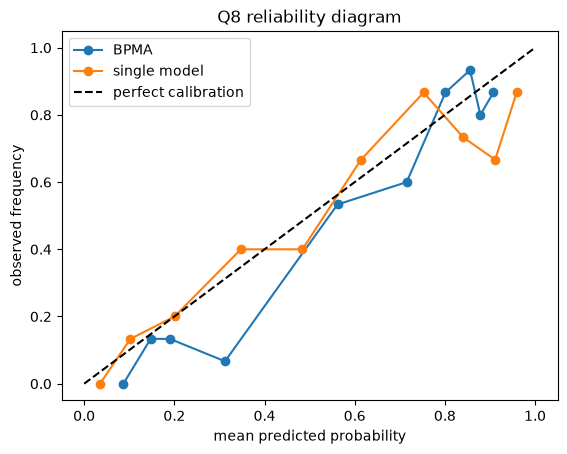

In [3]:
for label, probabilities in [('BPMA', bpma_proba), ('single model', single_proba)]:
    observed, predicted = calibration_curve(y_test, probabilities, n_bins=10, strategy='quantile')
    plt.plot(predicted, observed, marker='o', label=label)
plt.plot([0, 1], [0, 1], '--', color='black', label='perfect calibration')
plt.xlabel('mean predicted probability')
plt.ylabel('observed frequency')
plt.legend()
plt.title('Q8 reliability diagram')
plt.show()
# Repeat across data seeds and report confidence intervals, not one curve.


## Conclusion from the executed starter run

**Status: not falsified; preliminary support.** BPMA had Brier score 0.1349 versus 0.1760 for the single logistic model, indicating better probabilistic predictions on this split. The notebook currently shows a reliability diagram but does not numerically report calibration error, so repeated calibration metrics are needed to test the uncertainty claim.